In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.fraud_detection.data_loader import load_raw, reduce_memory
from src.fraud_detection.preprocessing import time_based_split
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [2]:
df = load_raw("../data/raw")
df = reduce_memory(df)
df["txn_day"] = df["TransactionDT"] / (24 * 3600)   # just for the comparison plot
print(f"Loaded shape: {df.shape}")

Loaded shape: (590540, 435)


In [3]:
#compare time-based split vs random stratified split
train_time, test_time = time_based_split(df, time_col="TransactionDT", test_size=0.2)
train_strat, test_strat = train_test_split(
    df, test_size=0.2, stratify=df["isFraud"], random_state=42
)

comparison = pd.DataFrame({
    "split_type": ["Time-based", "Time-based", "Random stratified", "Random stratified"],
    "set": ["train", "test", "train", "test"],
    "n_rows": [len(train_time), len(test_time), len(train_strat), len(test_strat)],
    "fraud_rate_%": [
        train_time["isFraud"].mean() * 100,
        test_time["isFraud"].mean() * 100,
        train_strat["isFraud"].mean() * 100,
        test_strat["isFraud"].mean() * 100,
    ],
})
comparison.round(2)

,split_type,set,n_rows,fraud_rate_%
0,Time-based,train,472432,3.51
1,Time-based,test,118108,3.44
2,Random stratified,train,472432,3.50
3,Random stratified,test,118108,3.50


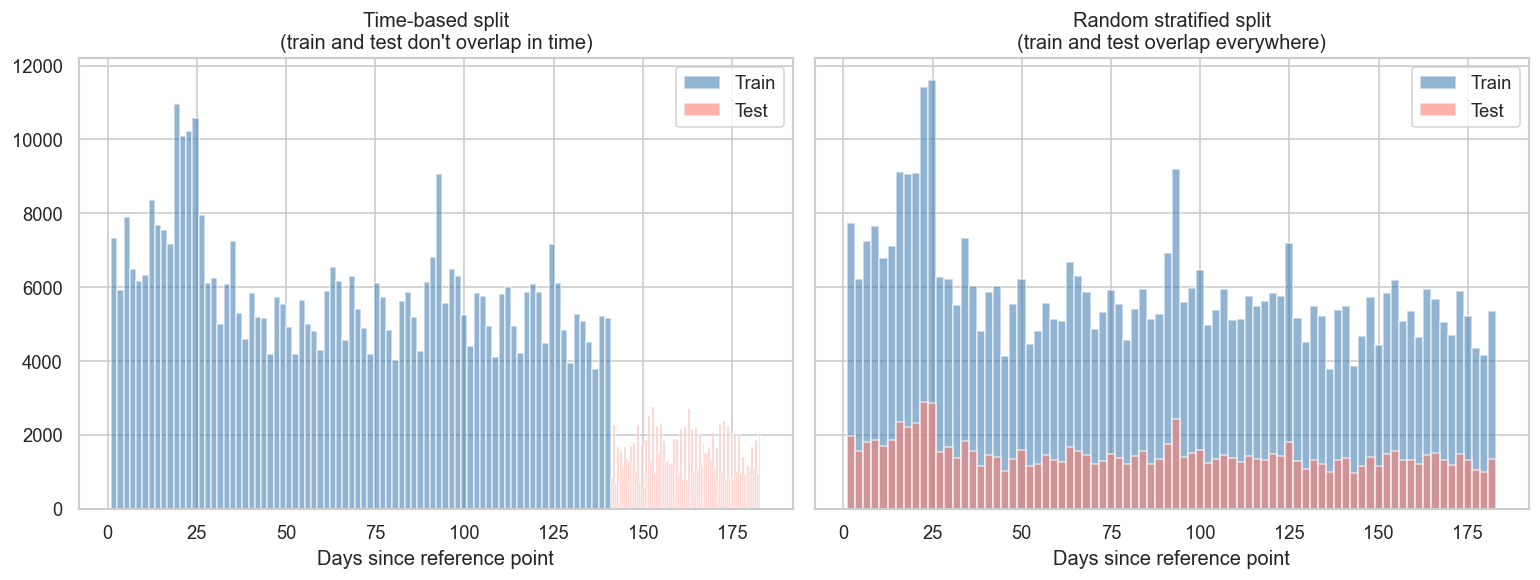

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

axes[0].hist(train_time["txn_day"], bins=80, alpha=0.6, label="Train", color="steelblue")
axes[0].hist(test_time["txn_day"], bins=80, alpha=0.6, label="Test", color="salmon")
axes[0].set_title("Time-based split\n(train and test don't overlap in time)")
axes[0].set_xlabel("Days since reference point")
axes[0].legend()

axes[1].hist(train_strat["txn_day"], bins=80, alpha=0.6, label="Train", color="steelblue")
axes[1].hist(test_strat["txn_day"], bins=80, alpha=0.6, label="Test", color="salmon")
axes[1].set_title("Random stratified split\n(train and test overlap everywhere)")
axes[1].set_xlabel("Days since reference point")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/06_split_comparison.png")
plt.show()

### Decision: time-based split adopted for all final reporting

The random stratified split interleaves train and test across the entire 6-month
window, meaning the model can train on later transactions and be evaluated on
earlier ones. In
production this never happens. The time-based split separates train (first ~80%
of days) from test (last ~20%), matching deployment reality.

**All final metrics in this project are reported on the time-based test set.**